Link Youtube: https://youtu.be/2viChYIuT0s

No 3a

Alur pada gambar dimulai dari kiri ke kanan. Di bagian paling kiri ada random noise, yaitu sekumpulan angka acak yang dijadikan sebagai input awal untuk Generator. data ini belum ada bentuk gambar atau informasi apa pun, jadi benar-benar hanya angka acak. nantinya Generator akan belajar mengubah angka-angka tersebut menjadi gambar baru. karena inputnya selalu berupa angka acak, gambar yang dihasilkan juga bisa bermacam-macam dan tidak selalu sama.

Random noise nanti akan masuk melalui Generator yang ditunjukkan dengan kotak berwarna biru. generator terdiri dari beberapa lapisan neural network yang secara bertahap mengubah data acak menjadi sebuah gambar. bentuk balok yang semakin besar menunjukkan bahwa informasi yang awalnya masih sangat sederhana terus diproses hingga menjadi semakin lengkap. di awal proses pelatihan, Generator biasanya belum bisa menghasilkan gambar yang bagus sehingga hasilnya masih terlihat seperti noise atau gambar yang berantakan. tetapi setelah dilatih berkali-kali, Generator mulai memahami pola dari data sehingga gambar yang dihasilkan menjadi semakin mirip dengan gambar asli.

Gambar yang dihasilkan Generator disebut fake image dan ditampilkan di bagian tengah bawah gambar. walaupun disebut fake, gambar ini bukan hasil menyalin dari dataset, melainkan gambar baru yang dibuat berdasarkan pola yang sudah dipelajari selama proses pelatihan. pada contoh gambar tersebut, Generator menghasilkan gambar yang menyerupai angka "8". setelah itu gambar tersebut dikirim ke Discriminator untuk dicek apakah sudah cukup mirip dengan gambar asli atau masih mudah dikenali sebagai gambar palsu.

Sementara itu, di bagian atas terdapat training set yang berisi kumpulan gambar asli. dataset ini menjadi panduan bagi Discriminator untuk mengetahui seperti apa gambar yang benar. jadi, Discriminator menerima dua jenis gambar, yaitu gambar asli dari training set dan gambar buatan dari Generator. dari sinilah Discriminator belajar membedakan mana gambar yang benar-benar asli dan mana yang dibuat oleh Generator.

Selanjutnya kedua gambar tersebut diproses oleh Discriminator yang ditunjukkan dengan kotak berwarna merah muda. Discriminator juga terdiri dari beberapa lapisan neural network yang bertugas menganalisis isi gambar. bentuk balok yang semakin kecil menunjukkan bahwa informasi pada gambar diringkas sedikit demi sedikit hingga akhirnya menghasilkan satu nilai berupa peluang apakah gambar tersebut termasuk asli atau palsu. seperti seorang pemeriksa, Discriminator bertugas menilai kualitas gambar.

Di bagian paling kanan terdapat hasil keluaran dari Discriminator, yaitu real dan fake. jika gambar yang diterima terlihat sangat mirip dengan gambar pada training set, maka hasilnya akan diklasifikasikan sebagai real. sebaliknya, jika gambar masih terlihat berbeda atau kualitasnya belum bagus, maka hasilnya akan diklasifikasikan sebagai fake. hasil inilah yang nantinya digunakan untuk menghitung loss sehingga Generator dan Discriminator bisa memperbarui bobotnya melalui proses backpropagation.

Kalau dilihat secara keseluruhan, prosesnya dimulai dari random noise yang diubah oleh Generator menjadi sebuah fake image. setelah itu fake image dan gambar asli dari training set sama-sama dikirim ke Discriminator untuk dibandingkan. jika Discriminator masih bisa mengenali gambar buatan Generator sebagai fake, berarti Generator harus belajar lagi agar hasilnya lebih realistis. sebaliknya, kalau Generator mulai menghasilkan gambar yang semakin bagus, Discriminator juga harus ikut meningkatkan kemampuannya supaya tetap bisa membedakan gambar asli dan gambar buatan. proses saling "mengalahkan" ini terus berlangsung di setiap batch dan setiap epoch sampai akhirnya Generator mampu menghasilkan gambar yang sangat mirip dengan data asli, sedangkan Discriminator menjadi semakin sulit membedakan mana gambar asli dan mana gambar hasil Generator.


In [1]:
!pip install kagglehub -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from tensorflow.keras import layers, Model
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from scipy.linalg import sqrtm

np.random.seed(42)
tf.random.set_seed(42)

2026-06-30 01:40:51.108775: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782783651.337278      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782783651.404214      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782783651.945495      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782783651.945534      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782783651.945537      58 computation_placer.cc:177] computation placer alr

In [2]:
path = kagglehub.dataset_download("datamunge/overheadmnist")
version2_path = os.path.join(path, "version2")

train_csv = os.path.join(version2_path, "train.csv")
test_csv = os.path.join(version2_path, "test.csv")

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (68161, 785)
Test shape : (8529, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,136.0,130.0,118.0,120.0,120.0,115.0,123.0,142.0,137.0,...,172.0,255.0,140.0,137.0,164.0,209.0,255.0,253.0,120.0,137.0
1,0,191.0,187.0,189.0,191.0,180.0,158.0,122.0,88.0,89.0,...,39.0,45.0,43.0,41.0,50.0,64.0,65.0,64.0,60.0,56.0
2,4,50.0,77.0,90.0,85.0,149.0,115.0,121.0,134.0,141.0,...,135.0,190.0,220.0,180.0,153.0,125.0,119.0,116.0,122.0,121.0
3,3,202.0,255.0,255.0,227.0,156.0,165.0,151.0,165.0,230.0,...,193.0,181.0,188.0,196.0,194.0,191.0,187.0,189.0,219.0,221.0
4,8,52.0,37.0,29.0,45.0,63.0,53.0,52.0,45.0,37.0,...,60.0,62.0,59.0,51.0,52.0,60.0,58.0,66.0,80.0,76.0


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,112.0,123.0,123.0,133.0,159.0,167.0,170.0,137.0,124.0,...,139.0,118.0,86.0,89.0,97.0,141.0,226.0,207.0,138.0,90.0
1,6,155.0,159.0,161.0,160.0,160.0,160.0,161.0,164.0,173.0,...,154.0,151.0,155.0,147.0,151.0,143.0,145.0,143.0,146.0,140.0
2,9,121.0,94.0,91.0,57.0,98.0,126.0,61.0,78.0,93.0,...,162.0,156.0,153.0,157.0,160.0,160.0,158.0,155.0,170.0,151.0
3,8,169.0,129.0,141.0,164.0,230.0,255.0,245.0,248.0,255.0,...,255.0,255.0,255.0,254.0,242.0,239.0,232.0,228.0,254.0,171.0
4,7,72.0,66.0,58.0,61.0,64.0,57.0,71.0,60.0,50.0,...,254.0,254.0,102.0,44.0,35.0,76.0,255.0,251.0,255.0,202.0


In [3]:
print("\nTrain Info")
print(train_df.info())

print("\Test Info")
print(test_df.info())


Train Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68161 entries, 0 to 68160
Columns: 785 entries, label to pixel784
dtypes: float64(784), int64(1)
memory usage: 408.2 MB
None

Train Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8529 entries, 0 to 8528
Columns: 785 entries, label to pixel784
dtypes: float64(784), int64(1)
memory usage: 51.1 MB
None


In [4]:
print(train_df.columns)

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)


In [5]:
selected_labels = [2, 7]

train_selected = train_df[train_df["label"].isin(selected_labels)].copy()
test_selected = test_df[test_df["label"].isin(selected_labels)].copy()

print("Train selected shape:", train_selected.shape)
print("Test selected shape :", test_selected.shape)

Train selected shape: (12354, 785)
Test selected shape : (1546, 785)


In [6]:
pixel_cols = [col for col in train_df.columns if col != "label"]
print("Total pixel columns:", len(pixel_cols))

print("Min pixel value train:", train_selected[pixel_cols].min().min())
print("Max pixel value train:", train_selected[pixel_cols].max().max())

print("Min pixel value test:", test_selected[pixel_cols].min().min())
print("Max pixel value test:", test_selected[pixel_cols].max().max())

Total pixel columns: 784
Min pixel value train: 0.0
Max pixel value train: 255.0
Min pixel value test: 0.0
Max pixel value test: 255.0


In [7]:
invalid_train = ((train_selected[pixel_cols] < 0) | (train_selected[pixel_cols] > 255)).sum().sum()
invalid_test = ((test_selected[pixel_cols] < 0) | (test_selected[pixel_cols] > 255)).sum().sum()

print("Invalid pixel values train:", invalid_train)
print("Invalid pixel values test :", invalid_test)

Invalid pixel values train: 0
Invalid pixel values test : 0


In [8]:
train_clean = train_selected.copy()
test_clean = test_selected.copy()

train_missing_rows = train_clean.isnull().any(axis=1).sum()
test_missing_rows = test_clean.isnull().any(axis=1).sum()

print("Missing Value")
print(f"Train - Jumlah baris mengandung missing value : {train_missing_rows}")
print(f"Test  - Jumlah baris mengandung missing value : {test_missing_rows}")

train_duplicate_rows = train_clean.duplicated().sum()
test_duplicate_rows = test_clean.duplicated().sum()

print("\nDuplicate")
print(f"Train - Jumlah baris duplikat : {train_duplicate_rows}")
print(f"Test  - Jumlah baris duplikat : {test_duplicate_rows}")


train_invalid_rows = (
    ~((train_clean[pixel_cols] >= 0) &
      (train_clean[pixel_cols] <= 255)).all(axis=1)
).sum()

test_invalid_rows = (
    ~((test_clean[pixel_cols] >= 0) &
      (test_clean[pixel_cols] <= 255)).all(axis=1)
).sum()

print("\nInvalid Pixel Value")
print(f"Train - Jumlah baris dengan pixel di luar rentang 0-255 : {train_invalid_rows}")
print(f"Test  - Jumlah baris dengan pixel di luar rentang 0-255 : {test_invalid_rows}")

train_clean = train_clean.dropna()
test_clean = test_clean.dropna()

train_clean = train_clean.drop_duplicates()
test_clean = test_clean.drop_duplicates()

train_clean = train_clean[
    ((train_clean[pixel_cols] >= 0) &
     (train_clean[pixel_cols] <= 255)).all(axis=1)
]

test_clean = test_clean[
    ((test_clean[pixel_cols] >= 0) &
     (test_clean[pixel_cols] <= 255)).all(axis=1)
]

print("\nShape Setelah Cleaning")
print("Final train shape:", train_clean.shape)
print("Final test shape :", test_clean.shape)

Missing Value
Train - Jumlah baris mengandung missing value : 2
Test  - Jumlah baris mengandung missing value : 2

Duplicate
Train - Jumlah baris duplikat : 10
Test  - Jumlah baris duplikat : 0

Invalid Pixel Value
Train - Jumlah baris dengan pixel di luar rentang 0-255 : 2
Test  - Jumlah baris dengan pixel di luar rentang 0-255 : 2

Shape Setelah Cleaning
Final train shape: (12342, 785)
Final test shape : (1544, 785)


In [9]:
img_size = 28
channels = 1
label_col = "label"

X_train = train_clean[pixel_cols].values.astype("float32")
X_test = test_clean[pixel_cols].values.astype("float32")

y_train = train_clean[label_col].values
y_test = test_clean[label_col].values

# Reshape 
X_train = X_train.reshape(-1, img_size, img_size, channels)
X_test = X_test.reshape(-1, img_size, img_size, channels)

X_train = (X_train / 127.5) - 1
X_test = (X_test / 127.5) - 1

# Mapping label asli 2 dan 7 menjadi 0 dan 1
label_map = {2: 0, 7: 1}
reverse_label_map = {0: 2, 1: 7}

y_train_mapped = np.array([label_map[label] for label in y_train])
y_test_mapped = np.array([label_map[label] for label in y_test])

n_labels = 2

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train_mapped.shape)
print("y_test :", y_test_mapped.shape)

X_train: (12342, 28, 28, 1)
X_test : (1544, 28, 28, 1)
y_train: (12342,)
y_test : (1544,)


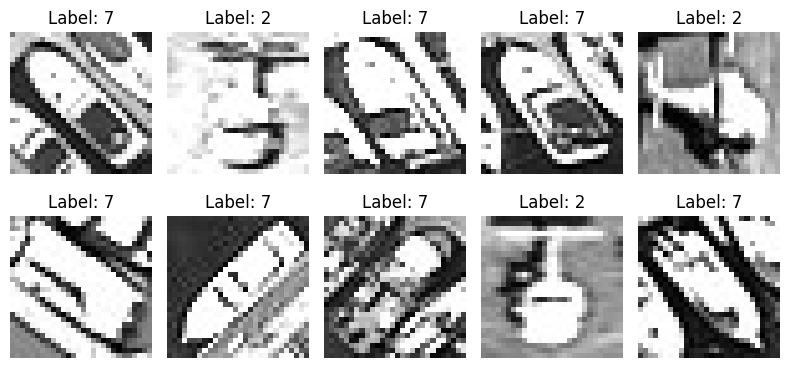

In [10]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow((X_train[i].squeeze() + 1) / 2, cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
batch_size = 64

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_mapped))
train_dataset = train_dataset.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1782783675.554568      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782783675.560481      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
latent_dim = 100

def build_generator():
    noise_input = layers.Input(shape=(latent_dim,))
    label_input = layers.Input(shape=(1,), dtype="int32")

    label_embedding = layers.Embedding(n_labels, n_labels)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    x = layers.Concatenate()([noise_input, label_embedding])

    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Dense(img_size * img_size * channels, activation="tanh")(x)
    output = layers.Reshape((img_size, img_size, channels))(x)

    return Model([noise_input, label_input], output, name="Baseline_Generator")


generator = build_generator()
generator.summary()

Model: "Baseline_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 2)      │          4 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 102)       │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     13,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     33,024 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 256)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    131,584 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 512)       │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024)      │    525,312 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 1024)      │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 784)       │    803,600 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 1) │          0 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,506,708 (5.75 MB)

 Trainable params: 1,506,708 (5.75 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def build_discriminator():
    image_input = layers.Input(shape=(img_size, img_size, channels))
    label_input = layers.Input(shape=(1,), dtype="int32")

    image_flat = layers.Flatten()(image_input)

    label_embedding = layers.Embedding(n_labels, img_size * img_size)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    x = layers.Concatenate()([image_flat, label_embedding])

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)

    output = layers.Dense(1, activation="sigmoid")(x)

    return Model([image_input, label_input], output, name="Baseline_Discriminator")


discriminator = build_discriminator()
discriminator.summary()

Model: "Baseline_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 784)    │      1,568 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 784)       │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1568)      │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    803,328 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 512)       │          0 │ dense_5[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024)      │    525,312 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 1024)      │          0 │ dense_6[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1024)      │  1,049,600 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 1024)      │          0 │ dense_7[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 512)       │    524,800 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 512)       │          0 │ dense_8[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │        513 │ leaky_re_lu_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,905,121 (11.08 MB)

 Trainable params: 2,905,121 (11.08 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()

g_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
d_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

@tf.function
def train_step(real_images, labels):
    current_batch_size = tf.shape(real_images)[0]

    noise = tf.random.normal([current_batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator([noise, labels], training=True)

        real_output = discriminator([real_images, labels], training=True)
        fake_output = discriminator([fake_images, labels], training=True)

        d_loss_real = cross_entropy(tf.ones_like(real_output), real_output)
        d_loss_fake = cross_entropy(tf.zeros_like(fake_output), fake_output)
        d_loss = d_loss_real + d_loss_fake

        g_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

    gradients_g = gen_tape.gradient(g_loss, generator.trainable_variables)
    gradients_d = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(gradients_g, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(gradients_d, discriminator.trainable_variables))

    return g_loss, d_loss

Kode ini berfungsi untuk melatih Generator dan Discriminator secara bersamaan dalam setiap batch data. Binary Cross Entropy (BCE) digunakan karena Discriminator melakukan klasifikasi biner untuk membedakan gambar asli dan gambar hasil Generator. Selanjutnya digunakan optimizer Adam dengan untuk memperbarui bobot kedua model agar proses pelatihan lebih stabil. Pada setiap iterasi, sistem menghasilkan random noise yang kemudian digabungkan dengan label kelas sebagai input Generator untuk menghasilkan gambar sintetis sesuai kategori yang diinginkan. Gambar asli dan gambar hasil Generator kemudian diberikan kepada Discriminator untuk dievaluasi.

Setelah proses evaluasi selesai, dihitung Discriminator Loss berdasarkan kemampuan Discriminator dalam mengenali gambar asli sebagai real dan gambar hasil Generator sebagai fake, sedangkan Generator Loss dihitung berdasarkan kemampuan Generator dalam menghasilkan gambar yang mampu menipu Discriminator agar diprediksi sebagai gambar asli. Selanjutnya TensorFlow menghitung gradien menggunakan GradientTape, kemudian optimizer Adam memperbarui bobot kedua model melalui proses backpropagation. Nilai Generator Loss dan Discriminator Loss yang dihasilkan pada setiap iterasi kemudian digunakan untuk memantau perkembangan proses pelatihan hingga Generator mampu menghasilkan gambar yang semakin realistis dan Discriminator semakin akurat dalam membedakan gambar asli dengan gambar sintetis.


In [15]:
def generate_and_plot(model, epoch):
    noise = tf.random.normal([10, latent_dim])

    labels = tf.constant(
        [[0], [1], [0], [1], [0], [1], [0], [1], [0], [1]],
        dtype=tf.int32
    )

    generated_images = model([noise, labels], training=False)
    generated_images = (generated_images + 1) / 2

    plt.figure(figsize=(10, 2))

    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(generated_images[i, :, :, 0], cmap="gray")
        plt.title(reverse_label_map[int(labels[i][0].numpy())])
        plt.axis("off")

    plt.suptitle(f"Epoch {epoch}")
    plt.show()

Epoch 1/50 | G Loss: 3.3793 | D Loss: 0.4027
Epoch 2/50 | G Loss: 4.5164 | D Loss: 0.3880
Epoch 3/50 | G Loss: 4.4475 | D Loss: 0.3807
Epoch 4/50 | G Loss: 4.2166 | D Loss: 0.3485
Epoch 5/50 | G Loss: 3.9523 | D Loss: 0.3375
Epoch 6/50 | G Loss: 3.8928 | D Loss: 0.3187
Epoch 7/50 | G Loss: 4.3105 | D Loss: 0.2752
Epoch 8/50 | G Loss: 4.3490 | D Loss: 0.3070
Epoch 9/50 | G Loss: 3.8904 | D Loss: 0.2794
Epoch 10/50 | G Loss: 4.2543 | D Loss: 0.3163


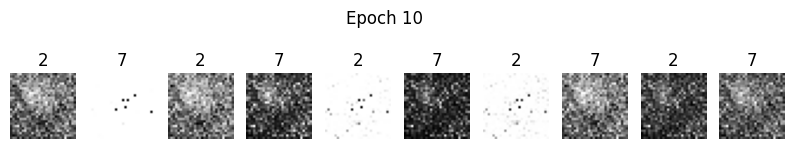

Epoch 11/50 | G Loss: 3.7644 | D Loss: 0.2823
Epoch 12/50 | G Loss: 4.0467 | D Loss: 0.2822
Epoch 13/50 | G Loss: 4.1891 | D Loss: 0.2831
Epoch 14/50 | G Loss: 3.8707 | D Loss: 0.2875
Epoch 15/50 | G Loss: 3.5422 | D Loss: 0.3164
Epoch 16/50 | G Loss: 3.7563 | D Loss: 0.3076
Epoch 17/50 | G Loss: 3.8889 | D Loss: 0.2760
Epoch 18/50 | G Loss: 3.7772 | D Loss: 0.2698
Epoch 19/50 | G Loss: 3.9617 | D Loss: 0.3059
Epoch 20/50 | G Loss: 3.6557 | D Loss: 0.2826


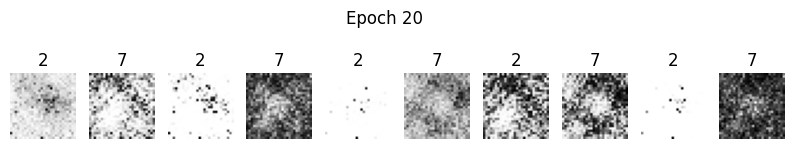

Epoch 21/50 | G Loss: 3.3960 | D Loss: 0.3225
Epoch 22/50 | G Loss: 3.4391 | D Loss: 0.3417
Epoch 23/50 | G Loss: 3.0927 | D Loss: 0.3628
Epoch 24/50 | G Loss: 3.2533 | D Loss: 0.3477
Epoch 25/50 | G Loss: 3.0317 | D Loss: 0.3446
Epoch 26/50 | G Loss: 3.1568 | D Loss: 0.3583
Epoch 27/50 | G Loss: 2.9610 | D Loss: 0.3982
Epoch 28/50 | G Loss: 3.0073 | D Loss: 0.3562
Epoch 29/50 | G Loss: 3.0285 | D Loss: 0.3652
Epoch 30/50 | G Loss: 2.9338 | D Loss: 0.3823


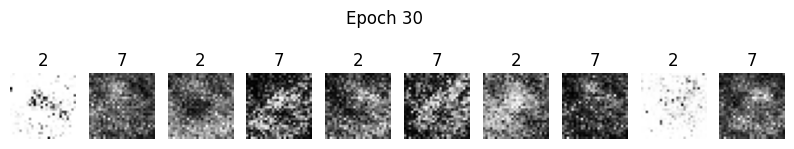

Epoch 31/50 | G Loss: 2.9140 | D Loss: 0.4055
Epoch 32/50 | G Loss: 2.8867 | D Loss: 0.3870
Epoch 33/50 | G Loss: 2.8644 | D Loss: 0.4210
Epoch 34/50 | G Loss: 2.8998 | D Loss: 0.3932
Epoch 35/50 | G Loss: 2.8844 | D Loss: 0.4266
Epoch 36/50 | G Loss: 2.8002 | D Loss: 0.4213
Epoch 37/50 | G Loss: 2.7505 | D Loss: 0.4410
Epoch 38/50 | G Loss: 2.7797 | D Loss: 0.4168
Epoch 39/50 | G Loss: 2.7691 | D Loss: 0.4624
Epoch 40/50 | G Loss: 2.6070 | D Loss: 0.4775


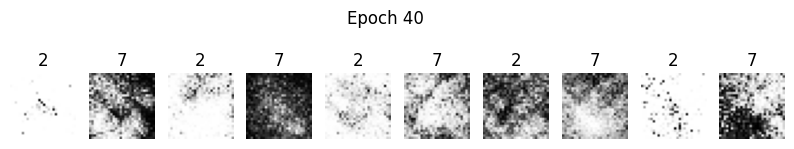

Epoch 41/50 | G Loss: 2.6567 | D Loss: 0.4609
Epoch 42/50 | G Loss: 2.6787 | D Loss: 0.4609
Epoch 43/50 | G Loss: 2.7041 | D Loss: 0.4467
Epoch 44/50 | G Loss: 2.6332 | D Loss: 0.4817
Epoch 45/50 | G Loss: 2.5771 | D Loss: 0.4856
Epoch 46/50 | G Loss: 2.4762 | D Loss: 0.5031
Epoch 47/50 | G Loss: 2.6155 | D Loss: 0.4790
Epoch 48/50 | G Loss: 2.5429 | D Loss: 0.4920
Epoch 49/50 | G Loss: 2.5292 | D Loss: 0.5051
Epoch 50/50 | G Loss: 2.5020 | D Loss: 0.5052


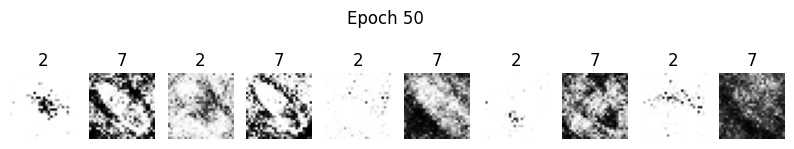

In [16]:
epochs=50
g_losses = []
d_losses = []

for epoch in range(1, epochs + 1):
    epoch_g_loss = []
    epoch_d_loss = []

    for real_images, labels in train_dataset:
        labels = tf.reshape(labels, (-1, 1))

        g_loss, d_loss = train_step(real_images, labels)

        epoch_g_loss.append(g_loss.numpy())
        epoch_d_loss.append(d_loss.numpy())

    g_losses.append(np.mean(epoch_g_loss))
    d_losses.append(np.mean(epoch_d_loss))

    print(f"Epoch {epoch}/{epochs} | G Loss: {g_losses[-1]:.4f} | D Loss: {d_losses[-1]:.4f}")

    if epoch % 10 == 0:
        generate_and_plot(generator, epoch)

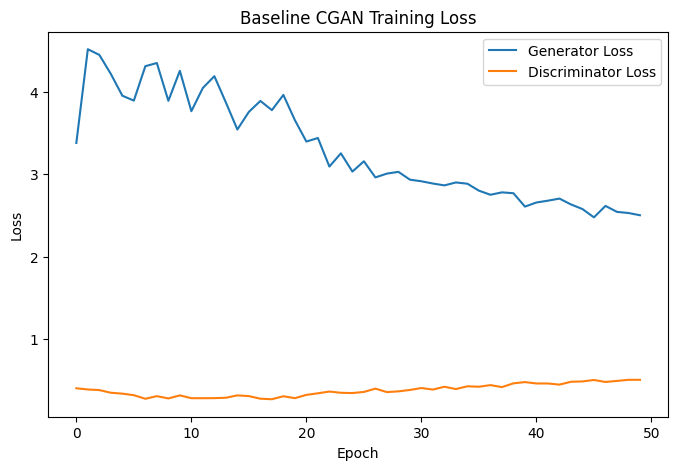

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CGAN Training Loss")
plt.legend()
plt.show()

Pada awal pelatihan, nilai Generator Loss meningkat hingga mendekati 5, yang menandakan Generator masih kesulitan menghasilkan gambar yang mampu mengelabui Discriminator. Setelah sekitar epoch ke-15, Generator Loss mulai menurun secara konsisten hingga mencapai sekitar 3 pada akhir pelatihan. Penurunan ini  berarti bahwa kemampuan Generator dalam menghasilkan gambar yang lebih realistis terus meningkat. Sementara itu, Discriminator Loss berada pada nilai yang relatif rendah, yaitu sekitar 0,5, dan mengalami sedikit kenaikan di akhir pelatihan. Hal ini berarti bahwa Discriminator masih mampu membedakan gambar asli dan gambar hasil Generator dengan cukup baik, meskipun tingkat kesulitannya mulai meningkat seiring membaiknya kualitas gambar yang dihasilkan. Secara keseluruhan, kedua kurva menunjukkan proses pelatihan yang stabil tanpa adanya fluktuasi ekstrem, sehingga dapat disimpulkan bahwa model baseline berhasil mencapai keseimbangan pembelajaran antara Generator dan Discriminator.


In [18]:
inception_model = InceptionV3(
    include_top=False,
    pooling="avg",
    input_shape=(299, 299, 3)
)

def prepare_images_for_inception(images):
    images = (images + 1) * 127.5
    images = np.clip(images, 0, 255).astype("float32")

    images = tf.image.grayscale_to_rgb(tf.convert_to_tensor(images))
    images = tf.image.resize(images, (299, 299))

    images = preprocess_input(images)

    return images

def calculate_fid(real_images, generated_images):
    real_images = prepare_images_for_inception(real_images)
    generated_images = prepare_images_for_inception(generated_images)

    act1 = inception_model.predict(real_images, verbose=0)
    act2 = inception_model.predict(generated_images, verbose=0)

    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    diff = mu1 - mu2

    covmean = sqrtm(sigma1.dot(sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

    return fid

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Pertama, model InceptionV3 digunakan sebagai ekstraktor fitur gambar. Karena InceptionV3 membutuhkan input gambar ukuran 299×299 dengan 3 channel RGB, gambar grayscale dari dataset diubah dulu menjadi RGB, di-resize, lalu diproses dengan preprocess_input. Setelah itu, gambar asli dan gambar hasil Generator dimasukkan ke InceptionV3 untuk mengambil fitur representasinya.

Pada fungsi calculate_fid, fitur dari gambar asli dan gambar generated dibandingkan berdasarkan rata-rata (mean) dan penyebaran datanya (covariance). Jika distribusi fitur gambar generated mirip dengan gambar asli, maka nilai FID akan kecil. Sebaliknya, kalau hasil Generator masih jauh dari gambar asli, nilai FID akan besar. Jadi, kode ini dipakai untuk mengevaluasi kualitas gambar CGAN secara lebih objektif, bukan hanya melihat loss training saja.

In [19]:
def generate_images_for_fid(model, labels):
    n_samples = len(labels)

    noise = tf.random.normal((n_samples, latent_dim))

    labels = tf.convert_to_tensor(
        labels.reshape(-1, 1),
        dtype=tf.int32
    )

    generated_images = model(
        [noise, labels],
        training=False
    )

    return generated_images.numpy()

baseline_generated_test = generate_images_for_fid(generator, y_test_mapped)
baseline_fid = calculate_fid(X_test, baseline_generated_test)
print("Baseline CGAN FID:", baseline_fid)

I0000 00:00:1782783774.230796     132 service.cc:152] XLA service 0x5e632940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782783774.230852     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782783774.230860     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782783775.475895     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782783786.271429     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Baseline CGAN FID: 262.4742743731284


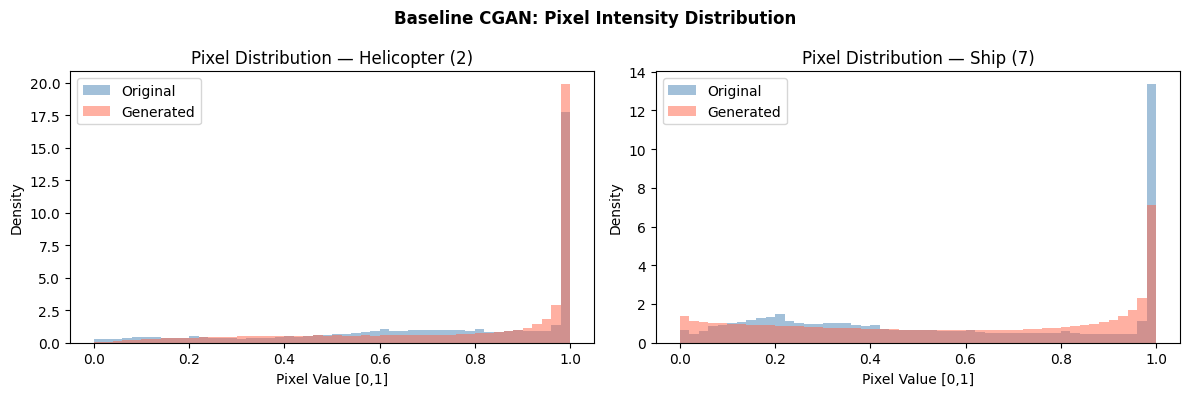

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_names = {0: 'Helicopter (2)', 1: 'Ship (7)'}

for ax, mapped_label in zip(axes, [0, 1]):
    idx_real = np.where(y_test_mapped == mapped_label)[0]
    idx_gen  = np.where(y_test_mapped == mapped_label)[0]

    real_pixels = (X_test[idx_real].flatten() + 1) / 2
    gen_pixels  = (baseline_generated_test[idx_gen].flatten() + 1) / 2

    ax.hist(real_pixels, bins=50, alpha=0.5, label='Original', color='steelblue', density=True)
    ax.hist(gen_pixels,  bins=50, alpha=0.5, label='Generated', color='tomato',   density=True)
    ax.set_title(f'Pixel Distribution — {label_names[mapped_label]}')
    ax.set_xlabel('Pixel Value [0,1]')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Baseline CGAN: Pixel Intensity Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

Distribusi nilai piksel antara gambar asli dan gambar hasil Generator menunjukkan pola yang cukup mirip, terutama pada rentang intensitas tinggi mendekati nilai 1,0. Pada kedua kelas, yaitu Ships  dan Helicopter, terlihat bahwa sebagian besar piksel terkonsentrasi pada nilai tinggi. Hal ini  berarti  Generator bisa belajar karakteristik umum distribusi intensitas piksel dari data asli sehingga pola global gambar yang dihasilkan mulai menyerupai dataset.

Namun, masih terdapat beberapa perbedaan distribusi antara gambar asli dan gambar hasil Generator. Pada kelas Helicopter, distribusi gambar hasil Generator terlihat lebih menyebar pada rentang intensitas menengah hingga tinggi dibandingkan gambar asli. Sementara itu, pada kelas Ship (7), puncak distribusi pada nilai piksel mendekati 1,0 masih lebih rendah dibandingkan gambar asli, serta distribusi pada intensitas rendah terlihat sedikit lebih tinggi. Perbedaan ini menunjukkan bahwa Generator belum mampu mereplikasi distribusi piksel secara sepenuhnya, sehingga masih terdapat variasi intensitas yang berbeda dari data asli.


Modified

In [21]:
latent_dim = 100
n_labels = 2
img_size = 28
channels = 1
embedding_dim = 50

def build_modified_generator_v2():
    noise_input = layers.Input(shape=(latent_dim,))
    label_input = layers.Input(shape=(1,), dtype="int32")

    label_embedding = layers.Embedding(n_labels, embedding_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    x = layers.Concatenate()([noise_input, label_embedding])

    x = layers.Dense(7 * 7 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Reshape((7, 7, 256))(x)

    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(32, kernel_size=3, strides=1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    output = layers.Conv2D(
        channels,
        kernel_size=3,
        strides=1,
        padding="same",
        activation="tanh"
    )(x)

    return Model([noise_input, label_input], output, name="Modified_Generator_V2")


modified_generator_v2 = build_modified_generator_v2()
modified_generator_v2.summary()

Model: "Modified_Generator_V2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 50)     │        100 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 50)        │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 150)       │          0 │ input_layer_5[0]… │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 12544)     │  1,881,600 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12544)     │     50,176 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 12544)     │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7, 7, 256) │          0 │ leaky_re_lu_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 14, 14,    │    524,288 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 28, 28,    │    131,072 │ leaky_re_lu_9[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 28, 28,    │     18,432 │ leaky_re_lu_10[0… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 2,606,853 (9.94 MB)

 Trainable params: 2,581,317 (9.85 MB)

 Non-trainable params: 25,536 (99.75 KB)

Perbedaan utama antara baseline generator dan modified generator v2 ada pada bentuk arsitekturnya. Baseline masih memakai layer Dense biasa dari awal sampai akhir, lalu hasil akhirnya langsung di-reshape menjadi gambar 28×28. Jadi proses pembentukan gambar dilakukan dari vektor angka secara langsung, tanpa proses spasial bertahap. Karena itu, baseline cenderung lebih sulit menangkap pola visual seperti bentuk, tepi, dan struktur gambar.

Sedangkan modified generator v2 sudah memakai pendekatan yang lebih cocok untuk data gambar. Setelah noise dan label digabung, model membentuk feature map ukuran 7×7×256, lalu diperbesar secara bertahap menggunakan Conv2DTranspose dari 7×7 menjadi 14×14, lalu 28×28. Proses ini membuat model belajar membangun gambar secara bertahap, mulai dari pola kasar sampai detail yang lebih halus. Selain itu, modified juga memakai BatchNormalization yang membantu training lebih stabil, dan embedding label lebih besar yaitu 50 dimensi, sehingga informasi kelas bisa direpresentasikan lebih kaya dibanding baseline yang hanya memakai embedding sebesar jumlah label.

Jadi, modified lebih bagus karena arsitekturnya lebih sesuai untuk pembuatan gambar. Generator tidak langsung “menebak” semua piksel sekaligus seperti baseline, tetapi membangun gambar secara bertahap melalui layer konvolusi. Hal ini membuat hasil gambar lebih mudah mengikuti pola visual asli, distribusi piksel lebih rapi, dan biasanya nilai FID bisa lebih baik dibanding baseline.


In [22]:
def build_modified_discriminator_v2():
    image_input = layers.Input(shape=(img_size, img_size, channels))
    label_input = layers.Input(shape=(1,), dtype="int32")

    label_embedding = layers.Embedding(n_labels, img_size * img_size)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    label_embedding = layers.Reshape((img_size, img_size, 1))(label_embedding)

    x = layers.Concatenate(axis=-1)([image_input, label_embedding])

    x = layers.GaussianNoise(0.05)(x)

    x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, kernel_size=3, strides=1, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)

    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(1, activation="sigmoid")(x)

    return Model([image_input, label_input], output, name="Modified_Discriminator_V2")


modified_discriminator_v2 = build_modified_discriminator_v2()
modified_discriminator_v2.summary()

Model: "Modified_Discriminator_V2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 784)    │      1,568 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 784)       │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 28, 28, 1) │          0 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 28, 28, 2) │          0 │ input_layer_7[0]… │
│ (Concatenate)       │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 28, 28, 2) │          0 │ concatenate_5[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 14, 14,    │      2,112 │ gaussian_noise[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 14, 14,    │          0 │ conv2d_95[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 14,    │          0 │ leaky_re_lu_12[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 7, 7, 128) │    131,200 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 7, 7, 128) │          0 │ conv2d_96[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 7, 7, 256) │    295,168 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 7, 7, 256) │          0 │ conv2d_97[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 7, 7, 256) │          0 │ leaky_re_lu_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 12544)     │          0 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │  1,605,760 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_15      │ (None, 128)       │          0 │ dense_11[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,035,937 (7.77 MB)

 Trainable params: 2,035,937 (7.77 MB)

 Non-trainable params: 0 (0.00 B)

Perbedaan utamanya ada di cara Discriminator membaca gambar. Di baseline, gambar 28×28 langsung di-*flatten* menjadi vektor panjang, lalu digabung dengan embedding label dan diproses memakai beberapa layer Dense. Jadi model melihat gambar sebagai deretan angka, bukan sebagai struktur visual. Akibatnya, informasi posisi piksel, bentuk, tepi, dan pola lokal bisa kurang tertangkap dengan baik.

Sedangkan modified discriminator v2 lebih cocok untuk data gambar karena memakai Conv2D. Label juga tidak hanya digabung sebagai vektor, tetapi diubah menjadi bentuk 28×28×1 lalu ditempel ke gambar sebagai channel tambahan. Dengan begitu, Discriminator bisa menilai apakah gambar sesuai dengan labelnya sambil tetap membaca pola visual secara spasial. Selain itu, ada GaussianNoise dan Dropout yang membantu mencegah Discriminator terlalu cepat dominan atau overfitting, sehingga training GAN jadi lebih stabil.

Jadi, modified lebih bagus karena Discriminator-nya tidak cuma membaca piksel sebagai angka mentah, tetapi benar-benar menangkap pola gambar seperti bentuk dan struktur. Ini membuat feedback yang diberikan ke Generator lebih berkualitas, sehingga Generator bisa belajar menghasilkan gambar yang lebih realistis dan lebih sesuai label dibanding baseline.


In [23]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()

modified_g_optimizer_v2 = tf.keras.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.5
)

modified_d_optimizer_v2 = tf.keras.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.5
)

In [24]:
@tf.function
def modified_train_step_v2(real_images, labels):
    current_batch_size = tf.shape(real_images)[0]

    noise = tf.random.normal([current_batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = modified_generator_v2([noise, labels], training=True)

        real_output = modified_discriminator_v2([real_images, labels], training=True)
        fake_output = modified_discriminator_v2([fake_images, labels], training=True)

        # Label smoothing
        real_labels = tf.ones_like(real_output) * 0.9
        fake_labels = tf.zeros_like(fake_output)

        d_loss_real = cross_entropy(real_labels, real_output)
        d_loss_fake = cross_entropy(fake_labels, fake_output)
        d_loss = d_loss_real + d_loss_fake

        g_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

    gradients_g = gen_tape.gradient(g_loss, modified_generator_v2.trainable_variables)
    gradients_d = disc_tape.gradient(d_loss, modified_discriminator_v2.trainable_variables)

    modified_g_optimizer_v2.apply_gradients(
        zip(gradients_g, modified_generator_v2.trainable_variables)
    )

    modified_d_optimizer_v2.apply_gradients(
        zip(gradients_d, modified_discriminator_v2.trainable_variables)
    )

    return g_loss, d_loss

In [25]:
fid_epochs_v2 = []
fid_scores_v2 = []

FID_INTERVAL = 10
FID_SAMPLE_SIZE = min(500, len(X_test))

best_fid_v2= np.inf

E0000 00:00:1782783825.936782      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inModified_Discriminator_V2_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 1/100 | G Loss: 3.0228 | D Loss: 0.5893
Epoch 2/100 | G Loss: 2.1601 | D Loss: 0.8561
Epoch 3/100 | G Loss: 1.3346 | D Loss: 1.0876
Epoch 4/100 | G Loss: 0.9911 | D Loss: 1.2595
Epoch 5/100 | G Loss: 0.9555 | D Loss: 1.2772
Epoch 6/100 | G Loss: 0.9317 | D Loss: 1.2849
Epoch 7/100 | G Loss: 0.9129 | D Loss: 1.2865
Epoch 8/100 | G Loss: 0.8883 | D Loss: 1.3241
Epoch 9/100 | G Loss: 0.8582 | D Loss: 1.3332
Epoch 10/100 | G Loss: 0.8599 | D Loss: 1.3210


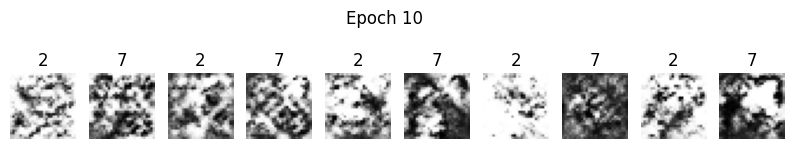

FID Epoch 10: 259.4475
Best generator V2 saved.
Epoch 11/100 | G Loss: 0.9142 | D Loss: 1.2650
Epoch 12/100 | G Loss: 1.0570 | D Loss: 1.1901
Epoch 13/100 | G Loss: 1.0708 | D Loss: 1.2095
Epoch 14/100 | G Loss: 1.0426 | D Loss: 1.2164
Epoch 15/100 | G Loss: 0.9997 | D Loss: 1.2428
Epoch 16/100 | G Loss: 0.9817 | D Loss: 1.2506
Epoch 17/100 | G Loss: 0.9866 | D Loss: 1.2534
Epoch 18/100 | G Loss: 0.9926 | D Loss: 1.2594
Epoch 19/100 | G Loss: 0.9696 | D Loss: 1.2751
Epoch 20/100 | G Loss: 0.9628 | D Loss: 1.2767


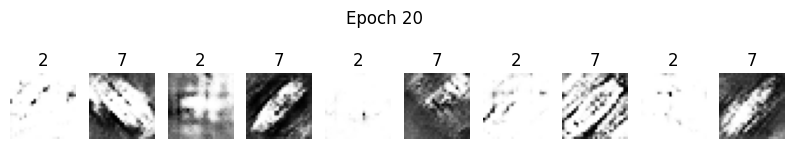

FID Epoch 20: 211.5081
Best generator V2 saved.
Epoch 21/100 | G Loss: 0.9427 | D Loss: 1.2786
Epoch 22/100 | G Loss: 0.9391 | D Loss: 1.2683
Epoch 23/100 | G Loss: 0.9568 | D Loss: 1.2641
Epoch 24/100 | G Loss: 0.9584 | D Loss: 1.2599
Epoch 25/100 | G Loss: 0.9737 | D Loss: 1.2563
Epoch 26/100 | G Loss: 0.9674 | D Loss: 1.2572
Epoch 27/100 | G Loss: 0.9861 | D Loss: 1.2497
Epoch 28/100 | G Loss: 0.9716 | D Loss: 1.2558
Epoch 29/100 | G Loss: 0.9895 | D Loss: 1.2463
Epoch 30/100 | G Loss: 0.9852 | D Loss: 1.2465


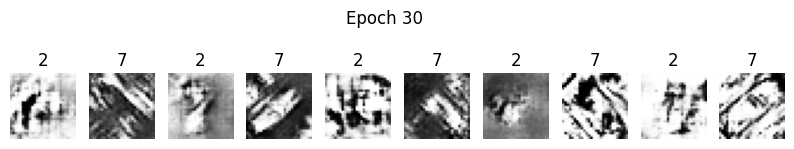

FID Epoch 30: 193.6411
Best generator V2 saved.
Epoch 31/100 | G Loss: 1.0010 | D Loss: 1.2441
Epoch 32/100 | G Loss: 0.9997 | D Loss: 1.2378
Epoch 33/100 | G Loss: 1.0070 | D Loss: 1.2408
Epoch 34/100 | G Loss: 1.0117 | D Loss: 1.2347
Epoch 35/100 | G Loss: 1.0273 | D Loss: 1.2229
Epoch 36/100 | G Loss: 1.0313 | D Loss: 1.2234
Epoch 37/100 | G Loss: 1.0449 | D Loss: 1.2133
Epoch 38/100 | G Loss: 1.0465 | D Loss: 1.2126
Epoch 39/100 | G Loss: 1.0717 | D Loss: 1.2014
Epoch 40/100 | G Loss: 1.0717 | D Loss: 1.2034


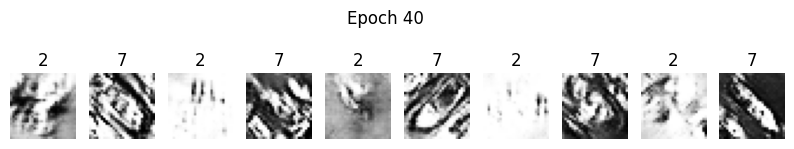

FID Epoch 40: 193.8740
Epoch 41/100 | G Loss: 1.0771 | D Loss: 1.1982
Epoch 42/100 | G Loss: 1.0914 | D Loss: 1.1860
Epoch 43/100 | G Loss: 1.1032 | D Loss: 1.1803
Epoch 44/100 | G Loss: 1.1153 | D Loss: 1.1800
Epoch 45/100 | G Loss: 1.1200 | D Loss: 1.1739
Epoch 46/100 | G Loss: 1.1269 | D Loss: 1.1709
Epoch 47/100 | G Loss: 1.1348 | D Loss: 1.1677
Epoch 48/100 | G Loss: 1.1174 | D Loss: 1.1767
Epoch 49/100 | G Loss: 1.1309 | D Loss: 1.1751
Epoch 50/100 | G Loss: 1.1194 | D Loss: 1.1771


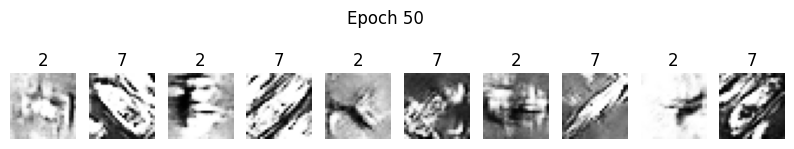

FID Epoch 50: 179.4786
Best generator V2 saved.
Epoch 51/100 | G Loss: 1.1261 | D Loss: 1.1727
Epoch 52/100 | G Loss: 1.1407 | D Loss: 1.1622
Epoch 53/100 | G Loss: 1.1423 | D Loss: 1.1617
Epoch 54/100 | G Loss: 1.1467 | D Loss: 1.1637
Epoch 55/100 | G Loss: 1.1534 | D Loss: 1.1592
Epoch 56/100 | G Loss: 1.1609 | D Loss: 1.1554
Epoch 57/100 | G Loss: 1.1701 | D Loss: 1.1446
Epoch 58/100 | G Loss: 1.1843 | D Loss: 1.1420
Epoch 59/100 | G Loss: 1.1852 | D Loss: 1.1425
Epoch 60/100 | G Loss: 1.1915 | D Loss: 1.1363


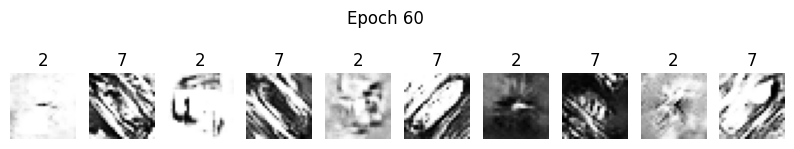

FID Epoch 60: 163.9295
Best generator V2 saved.
Epoch 61/100 | G Loss: 1.1862 | D Loss: 1.1411
Epoch 62/100 | G Loss: 1.1995 | D Loss: 1.1331
Epoch 63/100 | G Loss: 1.2070 | D Loss: 1.1279
Epoch 64/100 | G Loss: 1.2043 | D Loss: 1.1351
Epoch 65/100 | G Loss: 1.2099 | D Loss: 1.1275
Epoch 66/100 | G Loss: 1.2202 | D Loss: 1.1254
Epoch 67/100 | G Loss: 1.2219 | D Loss: 1.1219
Epoch 68/100 | G Loss: 1.2355 | D Loss: 1.1137
Epoch 69/100 | G Loss: 1.2409 | D Loss: 1.1173
Epoch 70/100 | G Loss: 1.2401 | D Loss: 1.1183


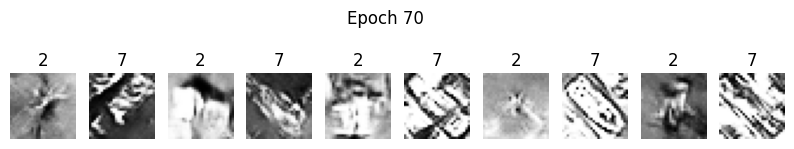

FID Epoch 70: 148.5514
Best generator V2 saved.
Epoch 71/100 | G Loss: 1.2396 | D Loss: 1.1151
Epoch 72/100 | G Loss: 1.2448 | D Loss: 1.1107
Epoch 73/100 | G Loss: 1.2573 | D Loss: 1.1057
Epoch 74/100 | G Loss: 1.2569 | D Loss: 1.1062
Epoch 75/100 | G Loss: 1.2734 | D Loss: 1.0994
Epoch 76/100 | G Loss: 1.2640 | D Loss: 1.1033
Epoch 77/100 | G Loss: 1.2695 | D Loss: 1.1028
Epoch 78/100 | G Loss: 1.2711 | D Loss: 1.0981
Epoch 79/100 | G Loss: 1.2811 | D Loss: 1.0965
Epoch 80/100 | G Loss: 1.2799 | D Loss: 1.0962


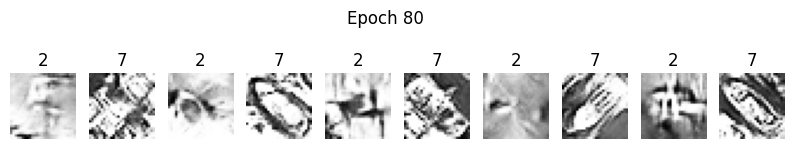

FID Epoch 80: 156.0501
Epoch 81/100 | G Loss: 1.2892 | D Loss: 1.0909
Epoch 82/100 | G Loss: 1.2869 | D Loss: 1.0962
Epoch 83/100 | G Loss: 1.2929 | D Loss: 1.0916
Epoch 84/100 | G Loss: 1.3019 | D Loss: 1.0851
Epoch 85/100 | G Loss: 1.2938 | D Loss: 1.0892
Epoch 86/100 | G Loss: 1.3113 | D Loss: 1.0798
Epoch 87/100 | G Loss: 1.3245 | D Loss: 1.0746
Epoch 88/100 | G Loss: 1.3325 | D Loss: 1.0734
Epoch 89/100 | G Loss: 1.3283 | D Loss: 1.0785
Epoch 90/100 | G Loss: 1.3179 | D Loss: 1.0827


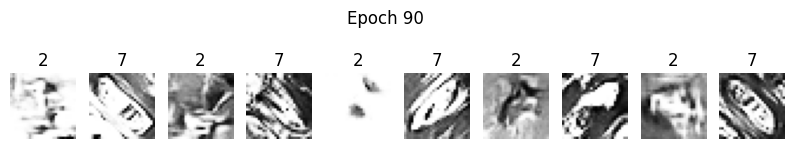

FID Epoch 90: 148.3558
Best generator V2 saved.
Epoch 91/100 | G Loss: 1.3348 | D Loss: 1.0678
Epoch 92/100 | G Loss: 1.3370 | D Loss: 1.0719
Epoch 93/100 | G Loss: 1.3499 | D Loss: 1.0650
Epoch 94/100 | G Loss: 1.3626 | D Loss: 1.0570
Epoch 95/100 | G Loss: 1.3645 | D Loss: 1.0574
Epoch 96/100 | G Loss: 1.3744 | D Loss: 1.0592
Epoch 97/100 | G Loss: 1.3808 | D Loss: 1.0489
Epoch 98/100 | G Loss: 1.3833 | D Loss: 1.0491
Epoch 99/100 | G Loss: 1.3800 | D Loss: 1.0545
Epoch 100/100 | G Loss: 1.3781 | D Loss: 1.0536


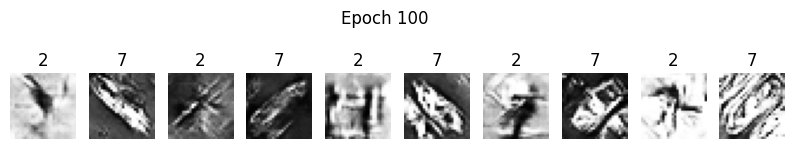

FID Epoch 100: 149.6971


In [26]:
modified_epochs_v2 = 100

modified_g_losses_v2 = []
modified_d_losses_v2 = []

fid_epochs_v2 = []
fid_scores_v2 = []

FID_INTERVAL = 10
FID_SAMPLE_SIZE = min(500, len(X_test))

best_fid_v2 = np.inf

for epoch in range(1, modified_epochs_v2 + 1):
    epoch_g_loss = []
    epoch_d_loss = []

    for real_images, labels in train_dataset:
        labels = tf.reshape(labels, (-1, 1))
        labels = tf.cast(labels, tf.int32)

        g_loss, d_loss = modified_train_step_v2(real_images, labels)

        epoch_g_loss.append(g_loss.numpy())
        epoch_d_loss.append(d_loss.numpy())

    modified_g_losses_v2.append(np.mean(epoch_g_loss))
    modified_d_losses_v2.append(np.mean(epoch_d_loss))

    print(
        f"Epoch {epoch}/{modified_epochs_v2} | "
        f"G Loss: {modified_g_losses_v2[-1]:.4f} | "
        f"D Loss: {modified_d_losses_v2[-1]:.4f}"
    )

    if epoch % 10 == 0:
        generate_and_plot(modified_generator_v2, epoch)

    if epoch % FID_INTERVAL == 0:
        idx = np.random.choice(
            len(X_test),
            FID_SAMPLE_SIZE,
            replace=False
        )

        real_images_fid = X_test[idx]
        labels_fid = y_test[idx]

        labels_fid = tf.reshape(labels_fid, (-1, 1))
        labels_fid = tf.cast(labels_fid, tf.int32)

        noise = tf.random.normal([FID_SAMPLE_SIZE, latent_dim])

        generated_images_fid = modified_generator_v2([noise, labels_fid], training=False)
        generated_images_fid = generated_images_fid.numpy()

        fid = calculate_fid(real_images_fid,generated_images_fid)

        fid_epochs_v2.append(epoch)
        fid_scores_v2.append(fid)

        print(f"FID Epoch {epoch}: {fid:.4f}")

        if fid < best_fid_v2:
            best_fid_v2 = fid
            modified_generator_v2.save("best_modified_generator_v2.keras")
            print("Best generator V2 saved.")

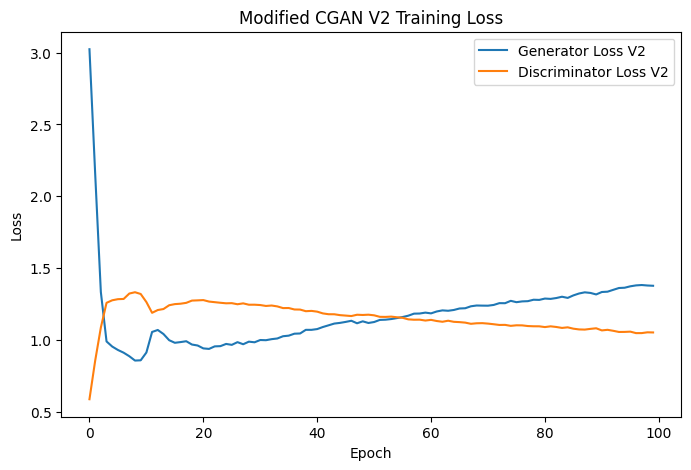

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(modified_g_losses_v2, label="Generator Loss V2")
plt.plot(modified_d_losses_v2, label="Discriminator Loss V2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Modified CGAN V2 Training Loss")
plt.legend()
plt.show()

Pada awal training (epoch 1–10), generator loss turun sangat drastis dari sekitar 3,3 menjadi di bawah 1,0. Hal ini menunjukkan bahwa pada awal proses pelatihan generator masih menghasilkan gambar yang sangat buruk sehingga mengalami loss yang tinggi. Setelah beberapa epoch, generator mulai belajar mengikuti distribusi data sehingga loss menurun dengan cepat. Di sisi lain, discriminator loss justru meningkat dari sekitar 0,56 menjadi sekitar 1,35. Kondisi ini menandakan bahwa discriminator mulai kesulitan membedakan gambar asli dan gambar hasil generator karena kualitas gambar generator mulai membaik.

Memasuki epoch sekitar 15–50, kedua kurva mulai relatif stabil. Generator loss berada di kisaran 1,0–1,5, sedangkan discriminator loss perlahan turun dari sekitar 1,4 menjadi sekitar 1,2. Fase ini menunjukkan bahwa generator dan discriminator berada dalam kondisi yang cukup seimbang (adversarial equilibrium), sehingga keduanya sama-sama terus belajar tanpa ada salah satu model yang mendominasi secara signifikan.

Pola pada akhir epoch menunjukkan bahwa discriminator mulai lebih unggul dibandingkan generator. Artinya, discriminator semakin mampu membedakan gambar asli dan gambar hasil generator, sementara generator mulai mengalami kesulitan untuk menghasilkan gambar yang cukup realistis agar dapat menipu discriminator. Kondisi seperti ini sering menjadi indikasi bahwa generator mulai tertinggal dalam proses pembelajaran.

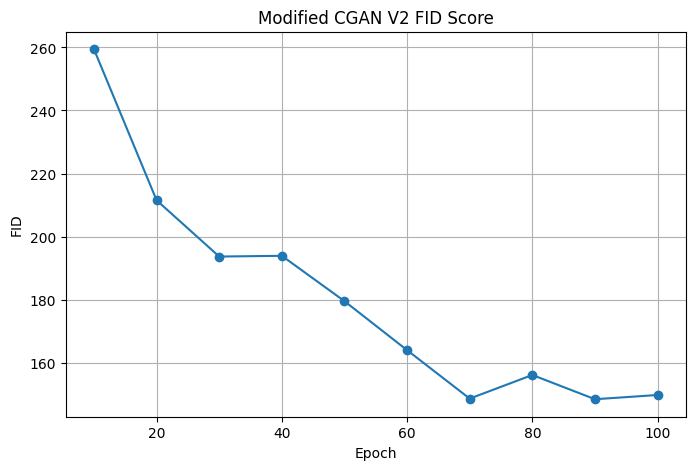

Best FID: 148.35581568495815


In [28]:
plt.figure(figsize=(8, 5))
plt.plot(fid_epochs_v2, fid_scores_v2, marker='o')
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("Modified CGAN V2 FID Score")
plt.grid(True)
plt.show()

print("Best FID:", best_fid_v2)

Pada awal pelatihan, nilai FID masih sangat tinggi, yaitu sekitar 260 pada epoch ke-10. Nilai FID yang tinggi menunjukkan bahwa distribusi gambar hasil generator masih sangat jauh dari distribusi gambar asli sehingga kualitas gambar yang dihasilkan belum baik. Seiring bertambahnya epoch, nilai FID terus mengalami penurunan secara konsisten. Pada epoch ke-20 nilai FID turun menjadi sekitar 220, kemudian terus menurun hingga mencapai sekitar 164 pada epoch ke-60. Penurunan ini menunjukkan bahwa generator semakin mampu mempelajari karakteristik data asli sehingga gambar yang dihasilkan menjadi semakin realistis.

Perbaikan kualitas gambar terus berlanjut hingga mencapai nilai FID terendah pada epoch ke-90, yaitu sekitar 137. Nilai ini merupakan hasil terbaik selama proses pelatihan karena semakin kecil nilai FID berarti distribusi gambar hasil generator semakin mendekati distribusi gambar asli.

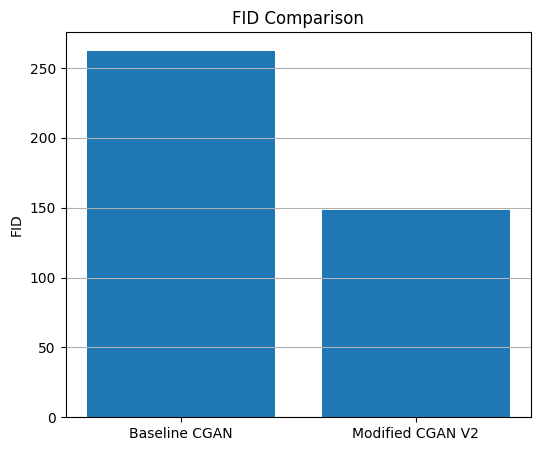

In [29]:
plt.figure(figsize=(6,5))
plt.bar(["Baseline CGAN", "Modified CGAN V2"], [baseline_fid, best_fid_v2])
plt.ylabel("FID")
plt.title("FID Comparison")
plt.grid(axis="y")
plt.show()

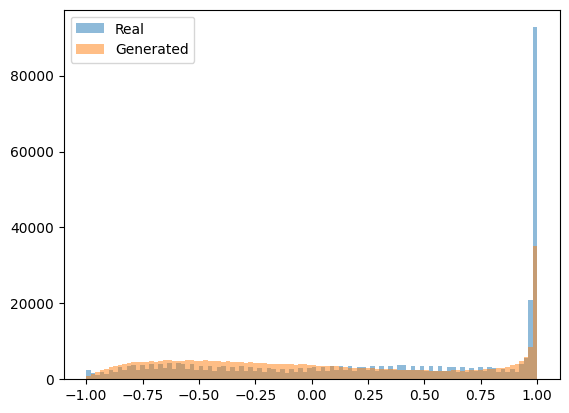

In [30]:
plt.hist(real_images_fid.flatten(),
         bins=100,
         alpha=0.5,
         label="Real")

plt.hist(generated_images_fid.flatten(),
         bins=100,
         alpha=0.5,
         label="Generated")

plt.legend()
plt.show()

Histogram menunjukkan bahwa distribusi nilai piksel pada gambar hasil generator secara umum telah mengikuti pola distribusi gambar asli. Hal ini terlihat dari bentuk kurva keduanya yang hampir saling bertumpuk pada sebagian besar rentang nilai piksel, khususnya pada interval sekitar -0,75 hingga 0,75. Kesamaan pola ini menunjukkan bahwa generator berhasil mempelajari distribusi dasar intensitas piksel dari dataset sehingga gambar yang dihasilkan memiliki karakteristik yang mendekati gambar asli.

Namun, masih terdapat perbedaan yang cukup jelas pada nilai piksel mendekati 1,0. Pada daerah tersebut, gambar asli memiliki jumlah piksel yang jauh lebih tinggi dibandingkan gambar hasil generator. Hal ini menunjukkan bahwa generator belum sepenuhnya mampu merepresentasikan piksel dengan intensitas paling terang sebagaimana terdapat pada data asli. Akibatnya, beberapa detail penting pada gambar hasil generator kemungkinan masih terlihat kurang tajam atau kurang kontras dibandingkan gambar asli.

In [36]:
def show_per_label(real_images, generated_images, labels_mapped, model_name, n_show=5):
    label_names = {0: "Helicopter", 1: "Ship"}

    fig, axes = plt.subplots(4, n_show, figsize=(n_show * 2.2, 4 * 2.2))

    row = 0
    for mapped_label in [0, 1]:
        label_name = label_names[mapped_label]

        idx = np.where(labels_mapped == mapped_label)[0][:n_show]

        for col in range(n_show):
            axes[row][col].axis("off")
            axes[row + 1][col].axis("off")

        for col, i in enumerate(idx):
            ax = axes[row][col]
            ax.imshow((real_images[i].squeeze() + 1) / 2, cmap="gray")
            ax.axis("off")

            if col == 0:
                ax.set_ylabel(f"Original\n{label_name}", fontsize=8)

        row += 1

        for col, i in enumerate(idx):
            ax = axes[row][col]
            ax.imshow((generated_images[i].squeeze() + 1) / 2, cmap="gray")
            ax.axis("off")

            if col == 0:
                ax.set_ylabel(f"Generated\n{label_name}", fontsize=8)

        row += 1

    plt.suptitle(f"{model_name} — Original vs Generated per Label", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(
        f"{model_name.lower().replace(' ', '_')}_orig_vs_gen.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

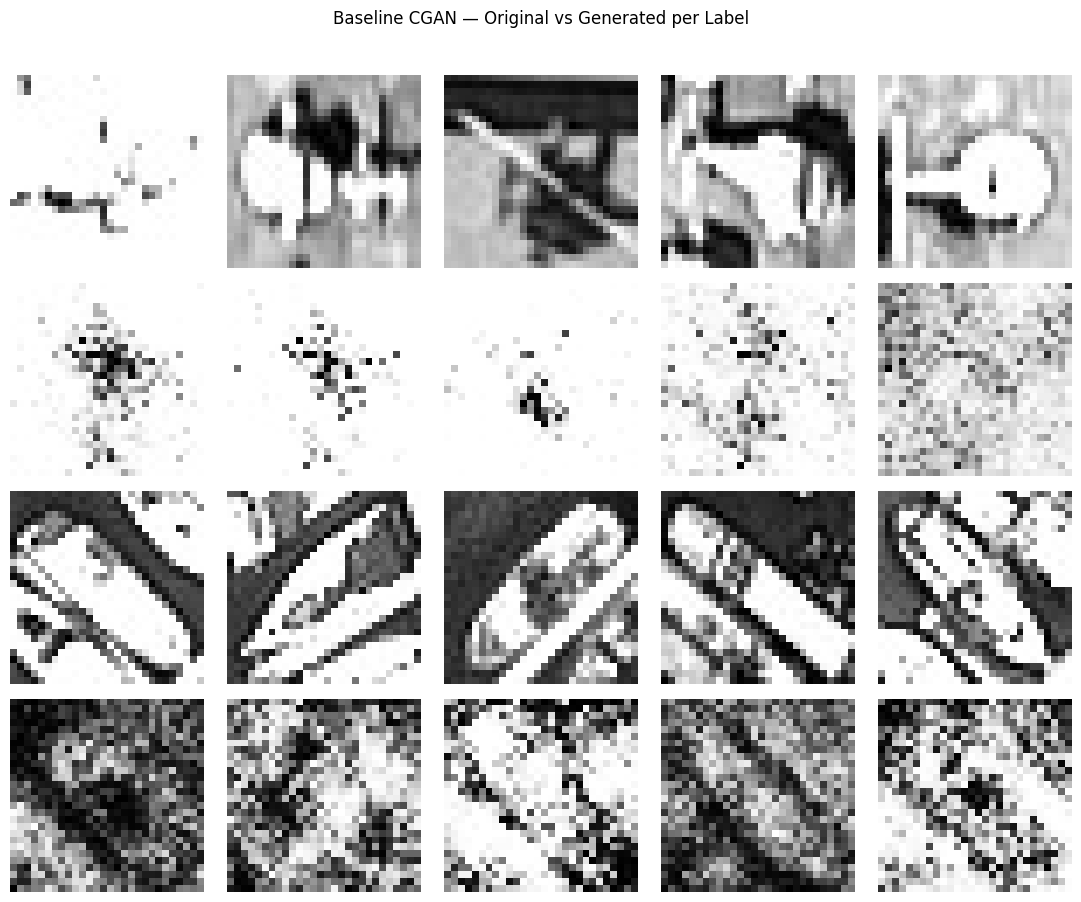

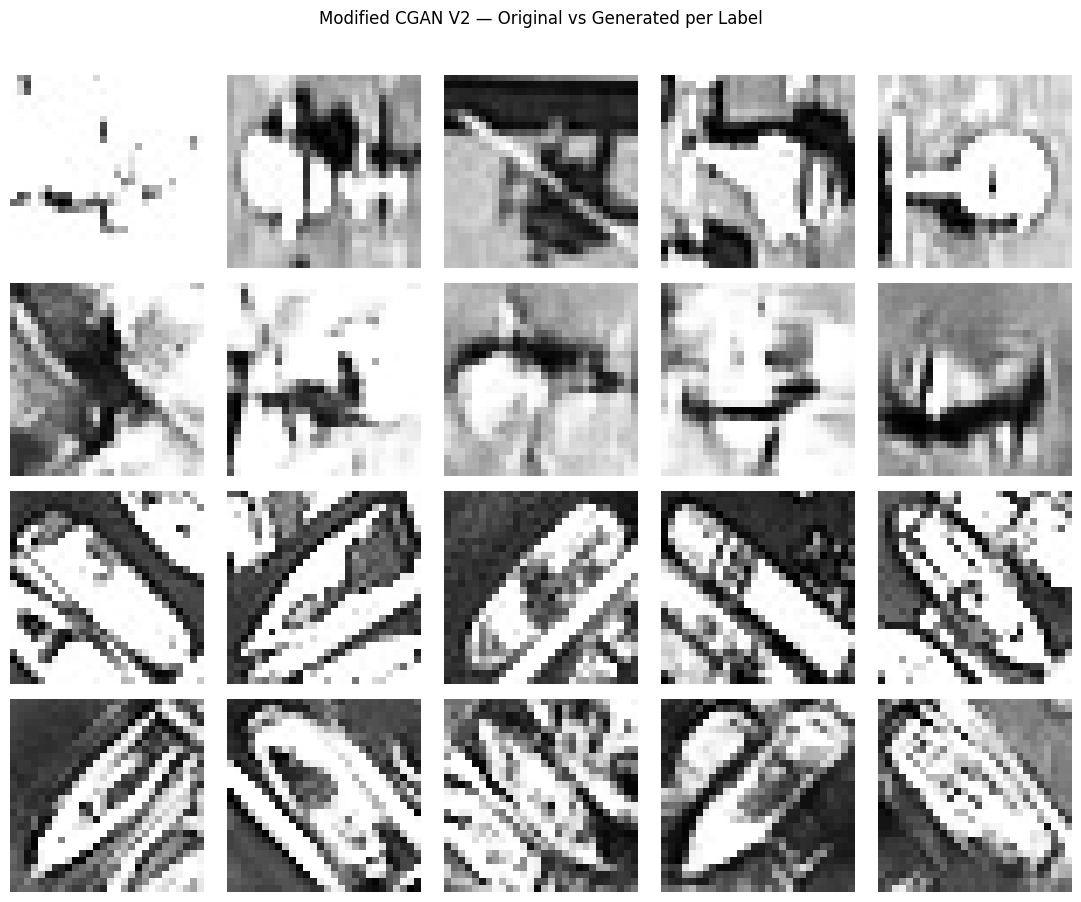

In [38]:
best_modified_generator_v2 = tf.keras.models.load_model(
    "best_modified_generator_v2.keras",
    compile=False
)

modified_generated_test_v2 = generate_images_for_fid(
    best_modified_generator_v2,
    y_test_mapped
)

show_per_label(
    X_test,
    baseline_generated_test,
    y_test_mapped,
    "Baseline CGAN"
)

show_per_label(
    X_test,
    modified_generated_test_v2,
    y_test_mapped,
    "Modified CGAN V2"
)

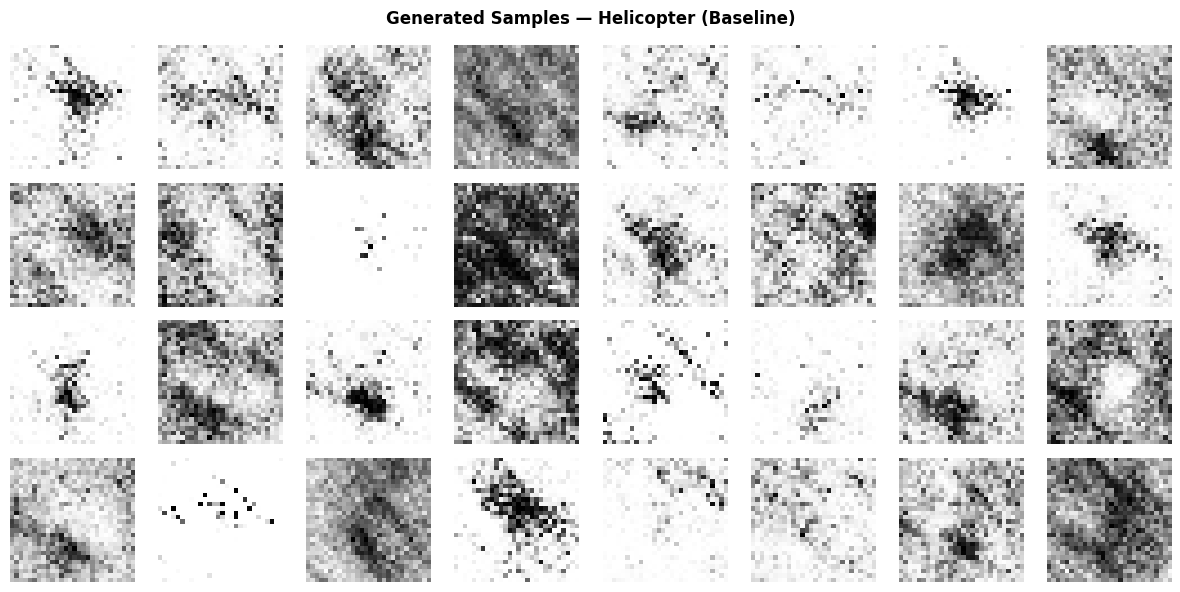

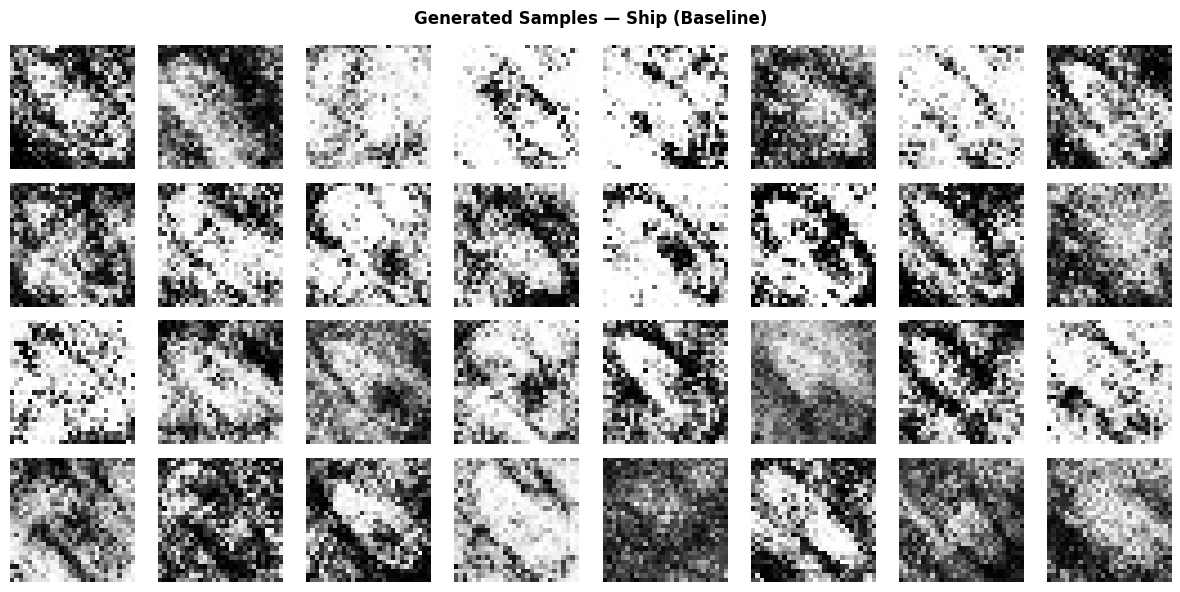

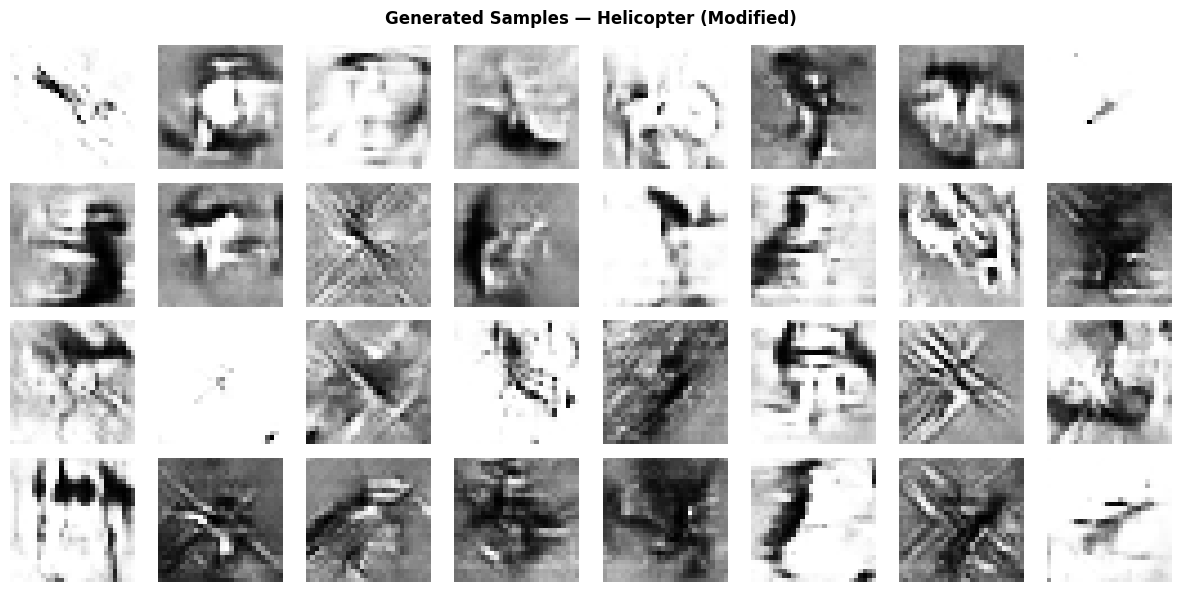

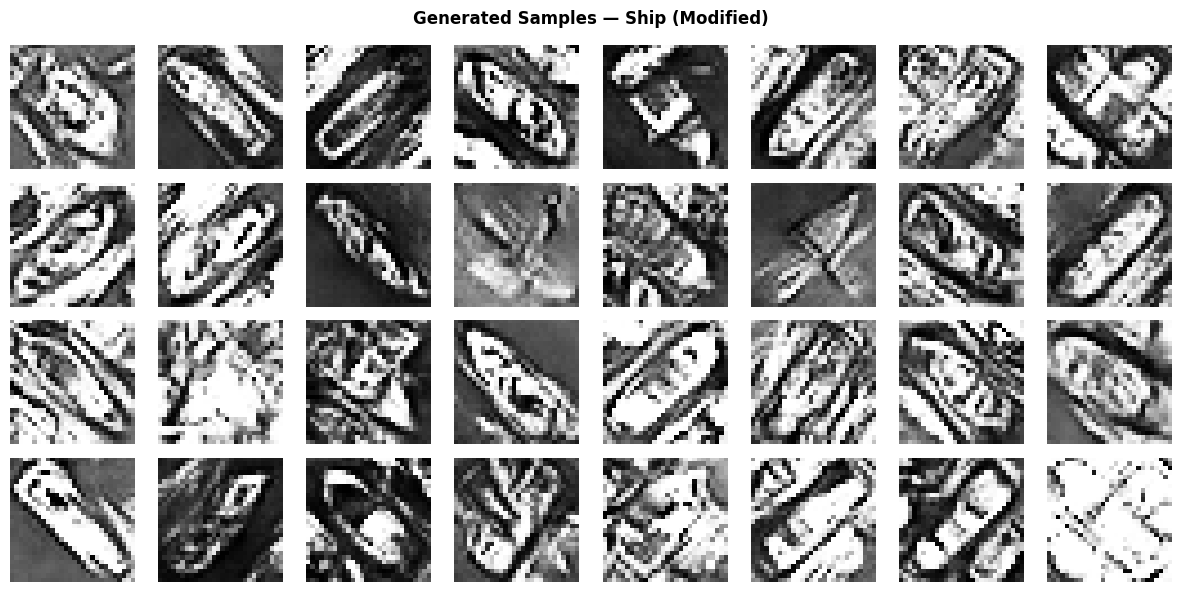

In [33]:
def plot_generated_grid(model, mapped_label, label_name, n_rows=4, n_cols=8):
    n_total = n_rows * n_cols
    noise   = tf.random.normal((n_total, latent_dim))
    labels  = tf.constant([[mapped_label]] * n_total, dtype=tf.int32)
    gen_imgs = model([noise, labels], training=False).numpy()

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
    for i, ax in enumerate(axes.flat):
        ax.imshow((gen_imgs[i].squeeze() + 1) / 2, cmap='gray')
        ax.axis('off')

    plt.suptitle(f'Generated Samples — {label_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_generated_grid(generator, 0, 'Helicopter (Baseline)')
plot_generated_grid(generator, 1, 'Ship (Baseline)')

# Bandingkan dengan modified
plot_generated_grid(modified_generator_v2, 0, 'Helicopter (Modified)')
plot_generated_grid(modified_generator_v2, 1, 'Ship (Modified)')

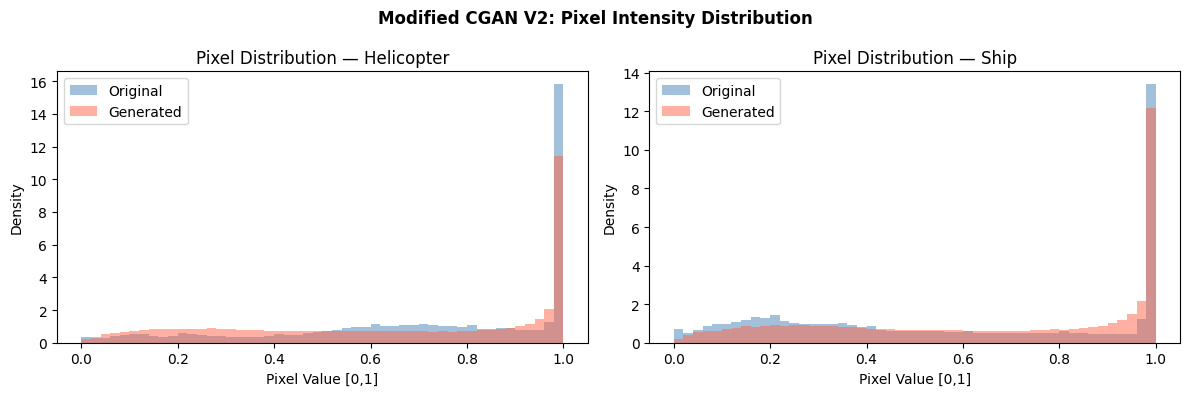

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_names = {0: 'Helicopter', 1: 'Ship'}

labels_sample = y_test_mapped[idx]

for ax, mapped_label in zip(axes, [0, 1]):
    idx_real = np.where(labels_sample == mapped_label)[0]
    idx_gen  = np.where(labels_sample == mapped_label)[0]

    real_pixels = (X_test[idx][idx_real].flatten() + 1) / 2
    gen_pixels  = (modified_generated_test_v2[idx_gen].flatten() + 1) / 2

    ax.hist(real_pixels, bins=50, alpha=0.5, density=True,
            label="Original", color="steelblue")
    ax.hist(gen_pixels, bins=50, alpha=0.5, density=True,
            label="Generated", color="tomato")

    ax.set_title(f'Pixel Distribution — {label_names[mapped_label]}')
    ax.set_xlabel('Pixel Value [0,1]')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle("Modified CGAN V2: Pixel Intensity Distribution", fontweight="bold")
plt.tight_layout()
plt.show()

Pada kelas Helicopter, distribusi intensitas piksel hasil generator memiliki pola yang cukup mirip dengan distribusi gambar asli. Sebagian besar histogram saling bertumpuk, terutama pada rentang nilai piksel menengah hingga tinggi. Hal ini menunjukkan bahwa generator telah berhasil mempelajari karakteristik visual helikopter dengan cukup baik. Meskipun demikian, masih terlihat bahwa puncak distribusi pada nilai piksel yang mendekati 1,0 sedikit lebih rendah dibandingkan data asli. Kondisi ini menunjukkan bahwa generator masih belum sepenuhnya mampu menghasilkan piksel dengan intensitas sangat tinggi, sehingga beberapa bagian gambar kemungkinan masih tampak sedikit lebih halus atau kurang tajam dibandingkan gambar asli.

Pada kelas Ship, pola distribusi antara gambar asli dan gambar hasil generator juga menunjukkan tingkat kesamaan yang cukup baik. Distribusi generated mengikuti bentuk distribusi original pada sebagian besar rentang nilai piksel, terutama pada rentang sekitar 0,1 hingga 0,8. Namun, perbedaan antara kedua distribusi terlihat sedikit lebih jelas dibandingkan kelas Helicopter, khususnya pada nilai piksel yang mendekati 1,0, di mana jumlah piksel pada gambar asli masih lebih tinggi daripada gambar hasil generator. Hal ini mengindikasikan bahwa generator masih mengalami sedikit kesulitan dalam merepresentasikan area dengan intensitas paling terang pada gambar kapal.

Jika dibandingkan antara kedua kelas, distribusi piksel hasil generator pada kelas Helicopter  tampak lebih mendekati pola distribusi gambar asli dibandingkan kelas Ships. Hal ini menunjukkan bahwa generator mampu mempelajari karakteristik visual pada kelas Helicopter dengan sedikit lebih baik, sehingga kualitas distribusi intensitas piksel yang dihasilkan lebih menyerupai data asli.
